In [83]:
import numpy as np
import pandas as pd
import os
import sys
import glob
import torch.nn as nn
from transformers import AutoConfig
from safetensors.torch import load_file  # comes with HF if safetensors installed
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import torch
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from BERT_classifier.Classify_report_with_BERT import tf_idf

In [84]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [85]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/stoxx_600"
dataset_path = "data/datasets/reports_subset_from_full_data_3"

In [86]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [87]:
cos_sim_path = "results/dataset__reports_subset_from_full_data_3_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1"
cos_sim_report_paths = glob.glob(cos_sim_path + "/*/*.csv")
len(cos_sim_report_paths)

813

In [88]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_1_0__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

813

In [ ]:
a = [os.path.basename(b).replace("_long.csv", "") for b in cos_sim_report_paths]

: 

: 

In [89]:
b = [os.path.basename(b).replace("_classifications.csv", "") for b in reports_results]

In [90]:
for cos in cos_sim_report_paths: 
    print(os.path.basename(cos).replace("_long.csv", "") in b)
    print(os.path.exists(cos))


True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [91]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,NACE,...,ISIN,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report
0,CA05335P1099,Auxly Cannabis Group Inc.,1,1987.0,CAN,05335P109,19960301.0,CAN,003V9K-E,1.30,...,CA05335P1099,BDGMQB,Auxly Cannabis Group Inc.,1.0,XLY-CA,1,SHARE,BDGMQB3,A,Auxly Cannabis Group Inc.2.pdf
1,JP3947800003,"MEGMILK SNOW BRAND Co., Ltd.",1,2009.0,JPN,J41966102,20220727.0,JPN,0833Y1-E,1.41,...,JP3947800003,B3ZC07,"MEGMILK SNOW BRAND Co., Ltd.",1.0,MMSBF-US,0,SHARE,BKQN701,A,"MEGMILK SNOW BRAND Co., Ltd.2.pdf"
2,ID1000167901,PT Cilacap Samudera Fishing Industry Tbk,0,1999.0,IDN,Y129H6108,20220527.0,IDN,@NA,3.12,...,ID1000167901,BMBMZG,PT Cilacap Samudera Fishing Industry Tbk,1.0,ASHA-ID,0,SHARE,BMBMZG9,A,PT Cilacap Samudera Fishing Industry Tbk3.pdf
3,JP3843250006,Hokuto Corporation,1,1964.0,JPN,J2224T102,19941202.0,JPN,05HY7N-E,1.30,...,JP3843250006,643271,Hokuto Corporation,1.0,1379-JP,1,SHARE,6432715,A,Hokuto Corporation1.pdf
4,VN000000VTQ6,Viet Trung Quang Binh Joint Stock Co,0,1961.0,VNM,Y937XS108,NaN,VNM,@NA,2.30,...,VN000000VTQ6,BMCR2W,Viet Trung Quang Binh Joint Stock Co,1.0,VTQ-VN,0,SHARE,BMCR2W8,A,Viet Trung Quang Binh Joint Stock Co3.pdf


In [92]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

834

In [ ]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

832

: 

: 

In [93]:
def get_tables(lines: list): 
    tables = []
    current_table = []

    for line in lines:
        if line.strip().startswith("|"):  # line belongs to a table
            current_table.append(line.strip())
        else:
            if current_table:  # table ended
                tables.append("\n".join(current_table))
                current_table = []

    # catch last table if file ends without empty lines
    if current_table:
        tables.append("\n".join(current_table))

    return tables

def preprocess_report(pdf_path: str) -> List[str]:

    with open(pdf_path, "r") as f: 
        text = f.read()
    
    lines = text.split("\n")

    tables = get_tables(lines)

    # drop if condidtion is True
    conditions = [
        # filter images
        lambda line: line == '<!-- image -->',
        
        #filter tables 
        lambda line: (line[0] == "|" and line[-1] == "|") if len(line) > 1 else False, 

        # filter headers
        lambda line: line.strip()[0] == "#" if len(line) > 0 else True,

        # filter sentences
        lambda line: "." not in line,
        
        # more than 50% is numbers
        lambda line: sum(ch.isalpha() for ch in line) / len(line) < 0.5,

        # minimum 3 words 
        lambda line: len(re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", '', line).strip().split(" ")) < 3,

        # Minimum 2 Sentences
        #lambda line: sum([0 if len(sentence.split(" ")) < 3 else 1 for sentence in split_text_into_sentences(line, "en")]) < 2

    ]
    accepted_lines = [line for line in lines if not any(condition(line) for condition in conditions)]
    accepted_lines += tables

    chunks = []

    for line in accepted_lines: 
        sentences = split_text_into_sentences(line, language='en')
        sentences = [sentence.strip() for sentence in sentences]
        sentences = [sentence for sentence in sentences if sentence != ""]
        new_chunks = [(" ".join(sentences[i:i+sentence_length])).strip() for i in range(0, len(sentences), 3)]

        chunks += new_chunks

    # if there is only one sentence in the last chunk, balance the two last chunks
    if len(split_text_into_sentences(chunks[-1], language = "en")) == 1: 
        last_two_chunks = chunks[-2] + " " + chunks[-1]
        chunks[-2] = last_two_chunks[0:(len(last_two_chunks) + 1) // 2]
        chunks[-1] = last_two_chunks[(len(last_two_chunks) + 1) // 2: (len(last_two_chunks)) - (len(last_two_chunks) + 1) // 2]

    chunks = [re.sub(r'\b\d+\.\d+\b', '', chunk) for chunk in chunks]
    chunks = [re.sub(r"[^a-zA-ZäöüÄÖÜß.\s]", '', chunk) for chunk in chunks]
    chunks = [re.sub(r"\s+", " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'\.{2,}', " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'^\d+\.\s*', " ", chunk) for chunk in chunks]
    chunks = [chunk.lower() for chunk in chunks]
    chunks = [chunk.strip() for chunk in chunks]

    return chunks

In [94]:
# ckpt = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
# ckpt = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
# model = classification_report_BERT.load_custom_bert_from_checkpoint(ckpt_path=ckpt)
# tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [95]:
import numpy as np
import pandas as pd

# assume df is your dataframe
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [96]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:
    
    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [97]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [98]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [ ]:
def max_class_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    
    max_sim = df["max_sim"].max()
    res_class = df[df["max_sim"] == max_sim].sum(0)[scores]

    return res_class.to_dict()

In [100]:
train_df = pd.read_csv("data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/full_data.csv")

training_reports = train_df["text"].to_list()

#Build TF-IDF model on all sentences from the training corpus
tfidf_vectorizer = tf_idf.build_tfidf_model(training_reports)

In [101]:
def tf_idf_weighted(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, k = 10) -> dict:
    shortened, ranked = tf_idf.select_top_sentences(
        report_paragraphs=df_full["Sentences"].to_list(),
        vectorizer=tfidf_vectorizer,
        max_words=2000
    )
    df_full = df_full.iloc[np.array(ranked)[:,2][:k]]
    
    #print(len(df_full))

    evaluation = logit_stacking(df_full.copy(), scores, threshold)

    return evaluation  

In [102]:
def only_use_paragraphs_with_large_cos_sim(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, df_cos_sim: pd.DataFrame = None, cos_sim_threshold = 0.4) -> dict:
        
    # apply threshold 
    df_cos_sim_scores = [column for column in df_cos_sim.columns if "Scores" in column]
    df_cos_sim.loc[:,"max_sim"] = df_cos_sim[df_cos_sim_scores].max(1)
    df_cos_sim["use_for_classification"] = df_cos_sim["max_sim"] > cos_sim_threshold

    # join into df_eval (BERT Classification)

    df_merged = pd.merge(df_full, df_cos_sim[["Sentences", "use_for_classification"]], on = "Sentences")
    df_merged = df_merged[df_merged["use_for_classification"]]

    scores = df.columns
    df_merged[scores] = df_merged[scores].apply(softmax, axis=1)
    df_softmax = df_merged[scores]

    evaluation = logit_stacking(df_softmax.copy(), scores, threshold)

    return evaluation  

In [103]:
ckpt_path = "results/BERT_models/relevancy_judge__2__num_layers_1__cos_thres_0.35__train_full_model_Truebert-base-uncased__train_full_model__all_labels/checkpoint-88"

tokenizer = AutoTokenizer.from_pretrained(ckpt_path) 

# load checkpoint
config = AutoConfig.from_pretrained(ckpt_path)

# 2. Build a model from config (bare BertForSequenceClassification)
model_binary = AutoModelForSequenceClassification.from_config(config)

# 3. Rebuild the SAME classifier architecture as in training
hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
num_layers = getattr(config, "custom_num_layers", 1)

layers = []
for i in range(num_layers):
    in_dim = config.hidden_size if i == 0 else hidden
    layers.append(nn.Linear(in_dim, hidden))
    layers.append(nn.GELU())
    layers.append(nn.Dropout(0.2))
layers.append(nn.Linear(hidden, 1))
model_binary.classifier = nn.Sequential(*layers)

# 4. Load weights from model.safetensors
state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
model_binary.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

# 5. Inference mode
model_binary.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [130]:
def binary_class(chunk): 
    inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model_binary(**inputs)
        logits = outputs.logits.squeeze(0)
        #logits = softmax(logits)

        probs = torch.sigmoid(logits)   # values between 0 and 1

        # label_scores = {
        #     model.config.id2label[i]: logits[i].item()
        #     for i in range(len(logits))
        # }
        # label_scores = dict(sorted(label_scores.items(), key=lambda x: x[1], reverse=True))
        # 
    return probs.item() > 0.5

In [131]:
def prefilter_binary(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, df_cos_sim: pd.DataFrame = None, cos_sim_threshold = 0.4, **kwargs) -> dict:

    print(len(df_full))

    # apply threshold 
    df_full["is_explanation"] = df_full["Sentences"].apply(binary_class)
    df_full = df_full[df_full["is_explanation"]]
    print(len(df_full))

    df_full["max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]

    print("\n".join(df_full["Sentences"].to_list()))
    print(df_full[["Sentences", "max_class_sim"]])
    #print(df_full)

    evaluation = majority_vote(df_full[scores].copy(), scores, threshold)

    return evaluation  

In [132]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def top3_acc(position_levels): 
    return np.mean(position_levels < 3)

In [133]:
for results_path in reports_results:
    n = os.path.basename(results_path).replace("_classifications.csv", "")
    if os.path.exists(os.path.join(cos_sim_path, n, n + "_long.csv")): 
        df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, n, n + "_long.csv"))
        df_eval = pd.read_csv(results_path, index_col=0)

sentence_in_cos_sim = []
for i in range(len(df_eval)): 
    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
    #print(df_cos_sim["Sentences"].to_list().index(df_eval["Sentences"][i]))
np.all(sentence_in_cos_sim)
df_cos_sim.head()
df_eval.head()

,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences
0,1.200440,-0.953116,-4.282497,0.534356,0.170768,-3.259419,-3.463269,-1.086244,-1.912185,9.268325,-3.508113,-3.034254,-0.281720,0.613309,-0.163544,0.232728,-0.349469,capital share in dekra akademie gmbh stuttgart...
1,-1.715533,-2.717427,-0.648301,6.594069,-0.320999,-2.550483,-3.047382,3.172629,-1.341321,1.633163,-1.359139,-2.906755,0.564509,-3.662364,-2.894477,2.981824,-1.698710,subsidiaries joint ventures joint operations a...
2,1.076430,-0.908954,-4.428759,0.401727,0.235349,-3.255651,-3.632106,-0.965311,-1.890442,9.371140,-3.545321,-3.017425,-0.349923,0.575754,-0.114297,0.253757,-0.320648,dekra managed to increase its revenue in the n...
3,1.318078,-1.235190,-4.387169,0.502955,0.499168,-3.230015,-3.514759,-0.901077,-1.543249,9.157784,-3.407559,-3.418607,-0.389022,-0.122693,-0.309297,0.554146,-0.195535,accumulative opportunities and risks can simul...
4,1.568511,-0.966604,-4.308718,0.151586,0.144111,-3.298960,-3.515039,-1.091774,-1.925130,9.178139,-3.651291,-3.082103,-0.473814,0.623319,0.174947,0.164057,-0.139436,in the financial year impairment losses of tho...


In [134]:
#for agg_func in [majority_vote, confidence_weighted_voting, logit_stacking]: 
#for agg_func in [tf_idf_weighted]: 

#for agg_func in [only_use_paragraphs_with_large_cos_sim, majority_vote, confidence_weighted_voting, logit_stacking, tf_idf_weighted]: 
for agg_func in [prefilter_binary]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")
    k = 30
    conf = 0.0
    #for cos_sim_threshold in [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]:
    for cos_sim_threshold in [0]:
    #for conf in [0.9]:
    #for k in [5,10,20,30,40,50]:
    #for k in [30]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            
            # ONLY USE TOP K
            df_eval = df_eval
            
            scores = df_eval.columns.drop("Sentences")
            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores]
            if agg_func == only_use_paragraphs_with_large_cos_sim: 

                base_name = os.path.basename(results_path).replace("_classifications.csv", "")

                # load cos sim df if it exists
                if os.path.exists(os.path.join(cos_sim_path, base_name, base_name + "_long.csv")): 
                    df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, base_name, base_name + "_long.csv"))
                    df_eval = pd.read_csv(results_path, index_col=0)
                else:
                    continue

                # check that the sentences are the same
                sentence_in_cos_sim = []
                for i in range(len(df_eval)): 
                    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
                if not np.all(sentence_in_cos_sim): 
                    print("Not the same reports in cos sim and df_eval: ", report_name)
                    continue

                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval, df_cos_sim=df_cos_sim 
                )

            else: 
                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval, k = k
                )
                
            # # get label of the report
            label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))


            try: 
                if isinstance(label, float) or isinstance(label, int):                     
                    if len(str(label).split(".")[0]) == 1: 
                        label = "0" + str(label) 

                label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
                evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
            except IndexError: 
                print(label, "index_error")
                label_description = ""
                evaluation = {}
            recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
            print(evaluation)
            df_recording = pd.DataFrame(recording)
            #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        print()
        print("Treshold: ", conf)
        #print("Top k (TF-IDF): ", k)
        print("cos_sim_threshold: ", cos_sim_threshold)
        print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        print("Top3 Acc.: ", top3_acc(df_recording["position_lvl_1"].dropna()))
        df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        y_true = df_recording["nace_lvl_1"] 
        y_pred = df_recording["first_class_1"]
        print(classification_report(y_true, y_pred))

--------

prefilter_binary

--------


  0%|                                                                                                                                                                                         | 0/813 [00:00<?, ?it/s]

628


/tmp/ipykernel_3924918/256318424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full["max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
  0%|▏                                                                                                                                                                              | 1/813 [00:26<5:52:01, 26.01s/it]

5
eam currently owns photovoltaic power plants through a holding company and subsidiaries in italy. the company has no employees.
the group owns and operates four solar pv power plants in italy as of yearend . the business is investing in and operating power plants that have similar economic characteristics.
solar power plants offer a power source that is environmentally superior to fossil fuels. the power plants do not expose the environment to any harm other than by occupying land and possibly altering its visual appearance. eams power plants are built with siliconbased solar panels and the power production facilities produce no harmful waste.
throughout eam solar asa owned and operated power plants. the power plants have a combined installed capacity of mw with an average annual power production of gwh p production.
eam acquired the first power plant in italy in . at the end of eam owned and operated power plants with a combined capacity of mw generating an average annual production

...

1
had a total of approximately million piped gas subscribers and approximately kilometres of natural gas pipelines in operation.
                                           Sentences max_class_sim
8  had a total of approximately million piped gas...             D
{'nace_lvl_1': 'D', 'position_lvl_1': 0, 'classes_lvl_1': 1, 'classification_lvl_1': {'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 1.0}, 'first_class_1': 'D'}
216


/tmp/ipykernel_3924918/256318424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full["max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
 37%|██████████████████████████████████████████████████████████████▋                                                                                                            | 298/813 [2:16:47<2:13:25, 15.54s/it]

8
embraces the evolution of concepts infrastructure and technologies that support local cloud services.
in addition to distributing games the company also distributes religious videos through the portal www.
indonesia is anticipated to be the southeast asia country with the fastest digital economy growth. the demand
the existence of the company and its subsidiaries can now be said to be the answer for its customers.
velocity of business operations including making it easier for employees to carry out their tasks. apart
recent and modern technology. as a result of digital transformation and the rising industrial revolution many
consumer website as well as for all marketplaces used by users. this feature will provide convenience
or related target industries. the subsidiary will open a booth and also carry out activities inside the
                                             Sentences max_class_sim
11   embraces the evolution of concepts infrastruct...             M
33   in addition to d

 37%|██████████████████████████████████████████████████████████████▋                                                                                                            | 298/813 [2:16:50<3:56:29, 27.55s/it]


KeyboardInterrupt: 

In [ ]:
df_full = df_eval

: 

In [ ]:
print(len(df_full))
df_full["is_explanation"] = df_full["Sentences"].apply(binary_class)
df_full = df_full[df_full["is_explanation"]]
print(len(df_full))
scores = df_full.columns
df_full[scores] = df_full[scores].apply(softmax, axis=1)
df_softmax = df_full[scores]
evaluation = logit_stacking(df_softmax.copy(), scores, threshold)


NameError: name 'df' is not defined

: 

In [ ]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,EAM Solar ASA1.txt_classifications.csv,35.11,Production of electricity,D,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 48.57...,K
1,Hamelin Gold Limited1.txt_classifications.csv,07.29,Mining of other non-ferrous metal ores,B,0.0,16,"{'B_MINING AND QUARRYING': 28.85582042050447, ...",B
2,Sitios Latinoamerica SAB de CV1.txt_classifica...,42.22,Construction of utility projects for electrici...,F,3.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 22.74...,K
3,Whitbread PLC3.txt_classifications.csv,55.1,Hotels and similar accommodation,I,2.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 51.61...,K
4,"Wanshih Electronic Co., Ltd1.txt_classificatio...",46.52,Wholesale of electronic and telecommunications...,G,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 298.5...,K
...,...,...,...,...,...,...,...,...
808,SoftBank Group Corp.1.txt_classifications.csv,61.2,Wireless telecommunications activities,J,15.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 113.1...,K
809,Amanat Holding PJSC1.txt_classifications.csv,64.99,"Other financial service activities, except ins...",K,0.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 92.22...,K
810,"NIPPON KANZAI Holdings Co., Ltd.1.txt_classifi...",68.31,Real estate agencies,L,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 10.97...,K
811,Webac Holding AG1.txt_classifications.csv,68.32,Management of real estate on a fee or contract...,L,1.0,16,"{'F_CONSTRUCTION': 1.0025578753336661, 'L_REAL...",F


: 

: 

In [ ]:
df_eval = pd.read_csv(reports_results[4], index_col=0)
df_eval

,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences
0,1.356129,-0.938107,-4.385613,0.219624,0.231118,-3.263761,-3.562938,-1.053005,-1.842897,9.289505,-3.605766,-3.089252,-0.449136,0.557421,0.044232,0.198982,-0.167902,the sensitivity analysis above is based on oth...
1,-1.860188,-1.523675,0.783928,8.296101,-0.452803,-0.827488,-3.336577,1.597020,-1.469543,1.156006,-2.659295,-1.582912,-0.905389,-3.343360,-2.802979,2.076991,-1.451702,financial assets and liabilities at fair value...
2,-1.808981,-1.660896,0.955385,8.321772,-0.488054,-0.933609,-3.322773,1.713280,-1.502435,1.030191,-2.604151,-1.664352,-0.836855,-3.403865,-2.817576,2.110342,-1.469030,. marketable securities held at the end of the...
3,-0.006807,-2.913710,-3.385005,3.467383,0.498463,-3.825386,-2.803913,1.284046,-1.470514,5.911236,-1.670760,-4.092206,1.355455,-1.865927,-2.437812,1.510852,-0.587526,note if the related party transaction conditio...
4,3.152318,-1.398265,-2.871725,-0.548155,-0.824874,-3.586877,-0.301425,-2.122835,-2.197562,5.846303,-2.868979,-3.172066,0.940637,1.719642,-0.190246,-0.616405,-0.459024,i le hao hong kong grasped the existing potent...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2060,1.212559,-1.249324,-4.291921,0.435585,1.652229,-3.094053,-3.508801,-0.922801,-1.149857,8.684509,-3.137770,-3.668743,-0.475437,-0.294588,-1.102888,0.520727,-0.357747,the remuneration of employees and the remunera...
2061,0.822735,-2.159231,-3.867137,0.314213,-0.791446,-2.562809,-2.245818,-0.392531,-0.136393,5.341374,-3.200089,-3.797929,-0.922002,-2.447647,1.418420,1.925939,1.637753,vi. other important information that is helpfu...
2062,1.038975,-1.099733,-4.099650,0.875304,1.305262,-3.045776,-3.153964,-1.020317,-1.105964,8.442141,-3.005119,-3.629550,-0.432762,-0.237602,-1.179791,0.581060,-0.460209,ii. in case where any member object or express...
2063,1.320084,-1.234775,-4.375323,0.406160,0.502995,-3.209983,-3.416813,-0.861201,-1.568791,9.151920,-3.360238,-3.394863,-0.266369,0.193492,-0.480272,0.286514,-0.084113,since customer relation and competition clause...


: 

: 

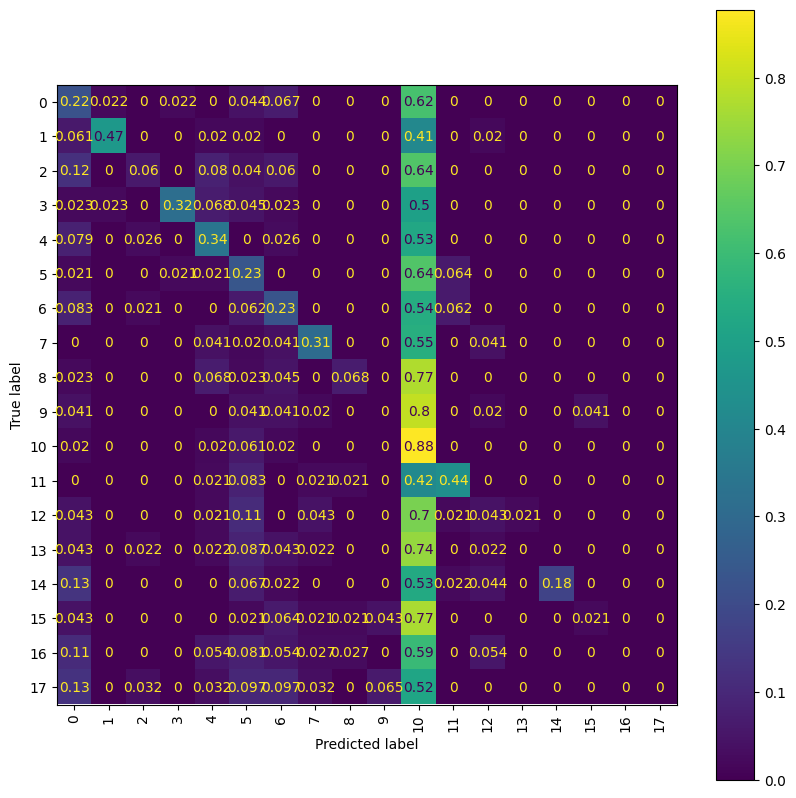

: 

: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [ ]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,EAM Solar ASA1.txt_classifications.csv,35.11,Production of electricity,D,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 48.57...,K
1,Hamelin Gold Limited1.txt_classifications.csv,07.29,Mining of other non-ferrous metal ores,B,0.0,16,"{'B_MINING AND QUARRYING': 28.85582042050447, ...",B
2,Sitios Latinoamerica SAB de CV1.txt_classifica...,42.22,Construction of utility projects for electrici...,F,3.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 22.74...,K
3,Whitbread PLC3.txt_classifications.csv,55.1,Hotels and similar accommodation,I,2.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 51.61...,K
4,"Wanshih Electronic Co., Ltd1.txt_classificatio...",46.52,Wholesale of electronic and telecommunications...,G,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 298.5...,K
...,...,...,...,...,...,...,...,...
808,SoftBank Group Corp.1.txt_classifications.csv,61.2,Wireless telecommunications activities,J,15.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 113.1...,K
809,Amanat Holding PJSC1.txt_classifications.csv,64.99,"Other financial service activities, except ins...",K,0.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 92.22...,K
810,"NIPPON KANZAI Holdings Co., Ltd.1.txt_classifi...",68.31,Real estate agencies,L,1.0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 10.97...,K
811,Webac Holding AG1.txt_classifications.csv,68.32,Management of real estate on a fee or contract...,L,1.0,16,"{'F_CONSTRUCTION': 1.0025578753336661, 'L_REAL...",F


: 

: 

In [ ]:
df_eval.max()

F                                                     8.399913
P                                                     9.252238
L                                                     8.858294
K                                                     8.458035
I                                                     8.893666
A                                                     1.135301
D                                                     8.814292
G                                                     8.884261
E                                                     8.894351
NO_CLASS                                               9.38966
B                                                     8.375397
J                                                      1.71885
H                                                     8.713749
Q                                                     9.393644
M                                                     7.726275
N                                                     6

: 

: 

In [ ]:
df_softmax = df_eval[scores].apply(softmax, axis=1)
df_softmax.mean(0)

F           0.018481
P           0.001116
L           0.025786
K           0.264671
I           0.014434
A           0.000079
D           0.011766
G           0.038926
E           0.005751
NO_CLASS    0.557044
B           0.001282
J           0.000056
H           0.011676
Q           0.003913
M           0.007400
N           0.011120
C           0.026499
dtype: float64

: 

: 

In [ ]:
df_softmax["max_class_sim"] = [scores[i] for i in np.argmax(df_softmax[scores], 1)]
df_softmax["max_sim"] = df_softmax[scores].max(1)
(df_softmax.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df_softmax)).to_dict()

{'NO_CLASS': 0.5458374264441067,
 'K': 0.25369001414264847,
 'G': 0.03352235863135649,
 'L': 0.02462083267320966,
 'C': 0.02370166013012811,
 'F': 0.01587810714266077,
 'I': 0.011986664714122923,
 'D': 0.011138023033318638,
 'H': 0.009784981470566102,
 'M': 0.006671975839747849,
 'N': 0.005733662571256167,
 'E': 0.0050266450254860895,
 'Q': 0.002891975105949976,
 'P': 0.0009671106126912338,
 'B': 0.0009499192196949308}

: 

: 